# RobotQ Demo

Composable augmentation toolkit for LeRobot v3 datasets.

This notebook walks through the full workflow:
1. Load a LeRobot dataset from HuggingFace Hub
2. Inspect the episode structure
3. Apply augmentations (Mirror, ColorJitter, SpeedWarp)
4. Preview before/after frames
5. Write the augmented dataset and get a visualizer link

## 1. Load a Dataset

Load 2 episodes from the ALOHA bimanual robot dataset. Each episode has 4 camera views and 14-DOF joint actions.

In [1]:
from robotq.io.loader import load_dataset

episodes = load_dataset("lerobot/aloha_static_cups_open", max_episodes=2)

ep = episodes[0]
print(f"Episodes loaded: {len(episodes)}")
print(f"Frames per episode: {ep.num_frames}")
print(f"Cameras: {ep.metadata.camera_names}")
print(f"Action dim: {ep.action_dim} (14-DOF bimanual)")
print(f"State dim: {ep.state_dim}")
print(f"FPS: {ep.metadata.fps}")
print(f"Robot: {ep.metadata.robot_type}")
print(f"Task: {ep.metadata.task_description}")

Episodes loaded: 2
Frames per episode: 400
Cameras: ['cam_high', 'cam_left_wrist', 'cam_low', 'cam_right_wrist']
Action dim: 14 (14-DOF bimanual)
State dim: 14
FPS: 50.0
Robot: aloha
Task: Pick up the plastic cup and open its lid.


## 2. Visualize Original Frames

Show a few frames from the first episode's high camera.

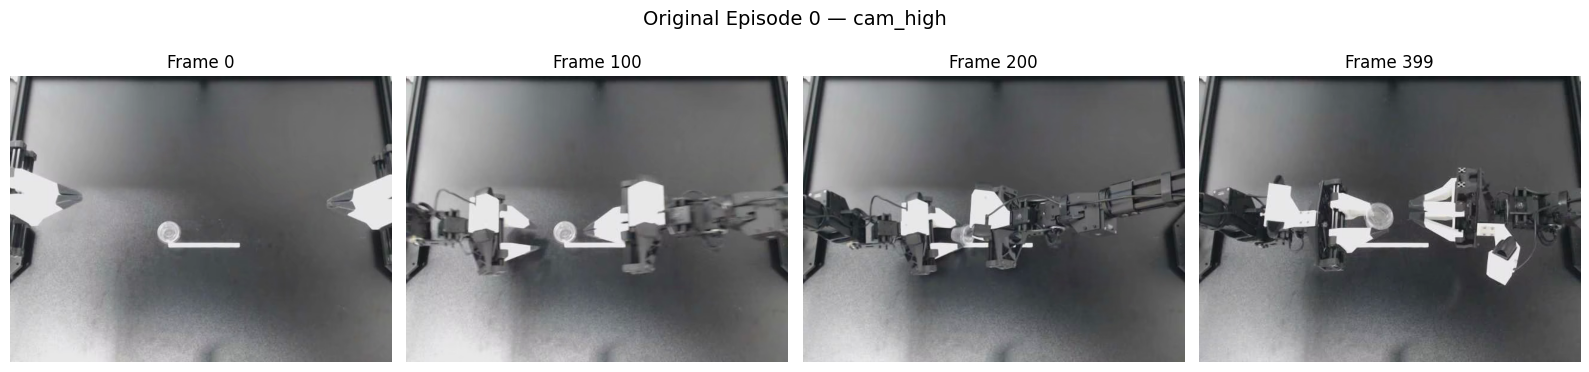

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Original Episode 0 — cam_high", fontsize=14)

frame_indices = [0, 100, 200, 399]
for ax, idx in zip(axes, frame_indices):
    ax.imshow(ep.frames["cam_high"][idx])
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Build an Augmentation Pipeline

Create a composable pipeline with Mirror (action-aware) + ColorJitter (temporally consistent) + SpeedWarp (temporal).

In [3]:
from robotq.core.pipeline import Compose
from robotq.core.augmentations.mirror import Mirror
from robotq.core.augmentations.color import ColorJitter
from robotq.core.augmentations.speed import SpeedWarp
from robotq.adapters.aloha import AlohaAdapter

pipeline = Compose([
    Mirror(adapter=AlohaAdapter(), p=1.0),    # Always mirror (for demo visibility)
    ColorJitter(brightness=0.3, contrast=0.2, p=1.0),  # Always jitter
    SpeedWarp(min_rate=0.9, max_rate=1.1, p=0.5),      # 50% chance of speed change
])

print(f"Pipeline: {pipeline}")

Pipeline: Compose(transforms=[Mirror(p=1.0, adapter=<robotq.adapters.aloha.AlohaAdapter object at 0x16b0a8b90>), ColorJitter(p=1.0, brightness=0.3, contrast=0.2, saturation=0.2, hue=0.05), SpeedWarp(p=0.5, min_rate=0.9, max_rate=1.1)], p=1.0)


## 4. Apply Augmentations

Augment each episode and compare before/after.

In [4]:
import copy

augmented = [pipeline(copy.deepcopy(ep)) for ep in episodes]

print(f"Original episode 0: {episodes[0].num_frames} frames")
print(f"Augmented episode 0: {augmented[0].num_frames} frames")
print(f"Original actions[0][:3]: {episodes[0].actions[0][:3]}")
print(f"Augmented actions[0][:3]: {augmented[0].actions[0][:3]}")
print(f"  (Actions differ because Mirror swaps L/R arms + negates waist joints)")

Original episode 0: 400 frames
Augmented episode 0: 375 frames
Original actions[0][:3]: [-0.01380583 -0.9526021   1.1688933 ]
Augmented actions[0][:3]: [ 0.0076699 -0.960272   1.1627575]
  (Actions differ because Mirror swaps L/R arms + negates waist joints)


## 5. Before / After Comparison

Side-by-side frames showing the effect of Mirror + ColorJitter.

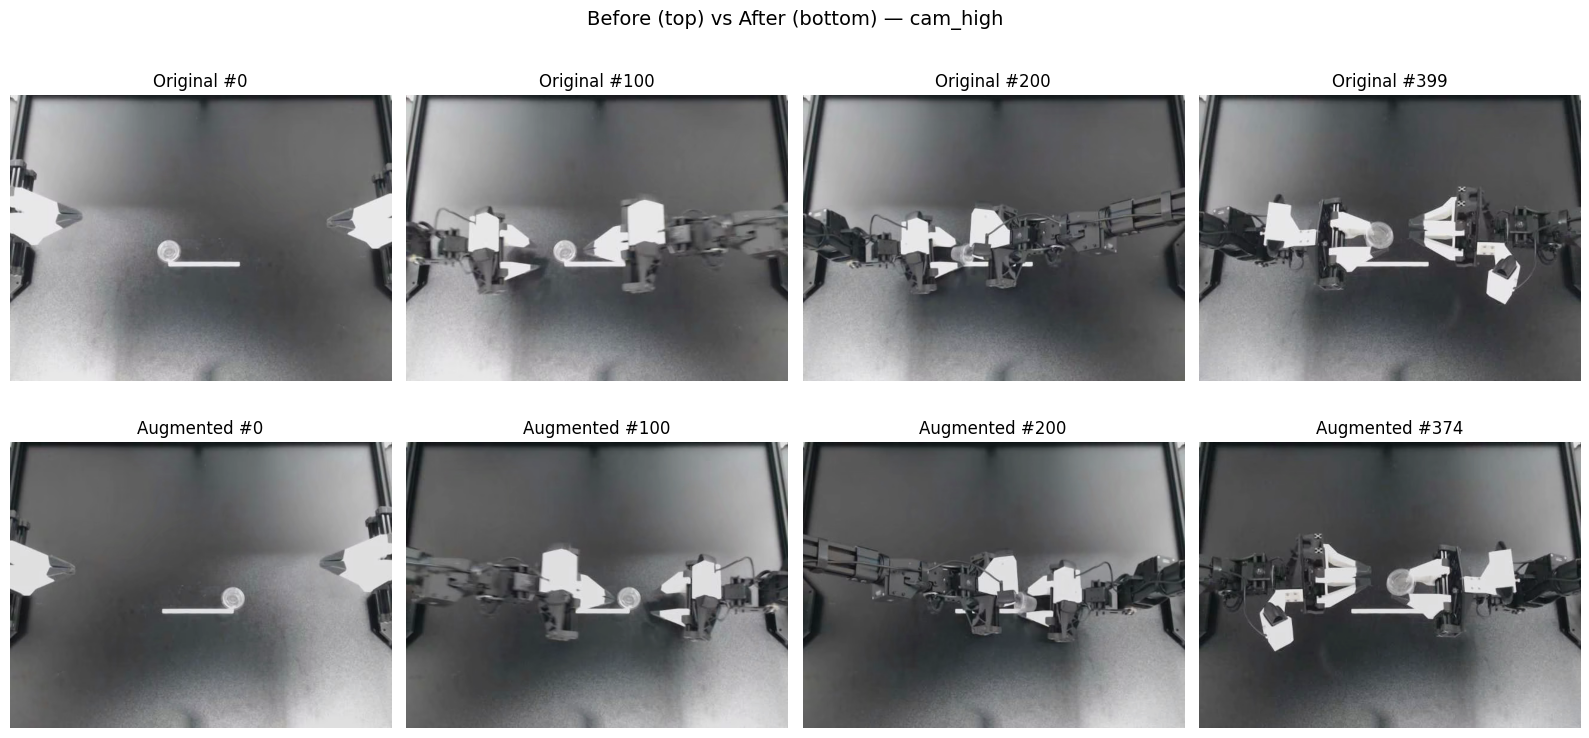

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Before (top) vs After (bottom) — cam_high", fontsize=14)

frame_indices = [0, 100, 200, 399]
n_aug = augmented[0].num_frames

for col, idx in enumerate(frame_indices):
    # Original
    axes[0][col].imshow(episodes[0].frames["cam_high"][idx])
    axes[0][col].set_title(f"Original #{idx}")
    axes[0][col].axis("off")
    
    # Augmented (clamp index if SpeedWarp changed length)
    aug_idx = min(idx, n_aug - 1)
    axes[1][col].imshow(augmented[0].frames["cam_high"][aug_idx])
    axes[1][col].set_title(f"Augmented #{aug_idx}")
    axes[1][col].axis("off")

plt.tight_layout()
plt.show()

## 6. Action Trajectory Comparison

Plot the first 3 action dimensions to show how Mirror swaps left/right arm joints.

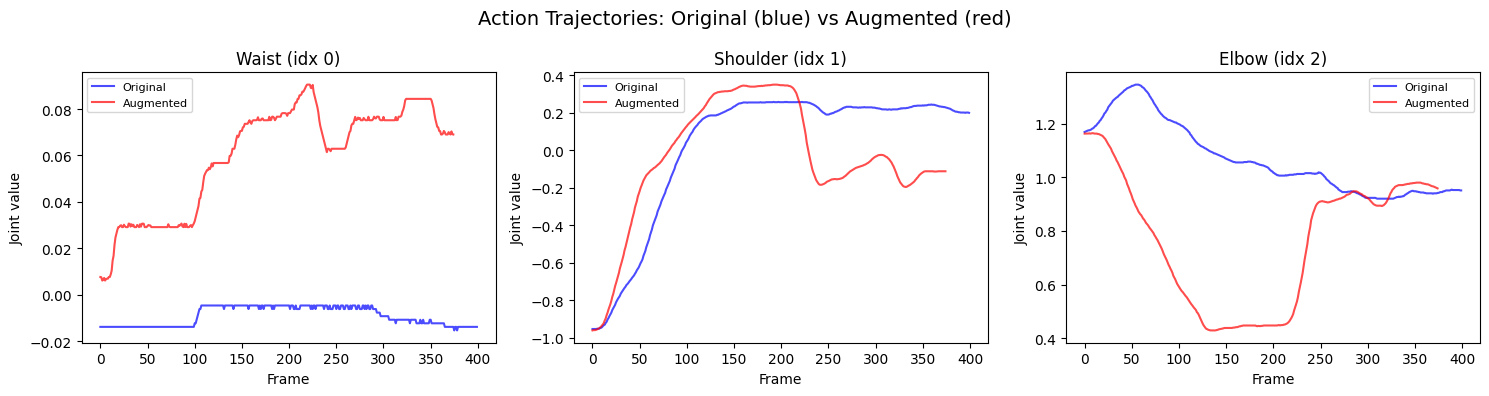

Note: Augmented waist (idx 0) is negated and comes from the RIGHT arm (idx 7)
Original action[0][0] (left waist):  -0.0138
Augmented action[0][0] (was right waist, negated): 0.0077


In [6]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Action Trajectories: Original (blue) vs Augmented (red)", fontsize=14)

labels = ["Waist (idx 0)", "Shoulder (idx 1)", "Elbow (idx 2)"]
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(episodes[0].actions[:, i], "b-", alpha=0.7, label="Original")
    ax.plot(augmented[0].actions[:, i], "r-", alpha=0.7, label="Augmented")
    ax.set_title(label)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Joint value")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Note: Augmented waist (idx 0) is negated and comes from the RIGHT arm (idx 7)")
print(f"Original action[0][0] (left waist):  {episodes[0].actions[0][0]:.4f}")
print(f"Augmented action[0][0] (was right waist, negated): {augmented[0].actions[0][0]:.4f}")

## 7. Write Augmented Dataset

Combine original + augmented episodes and write as a new LeRobot v3 dataset.

Set `local_only=True` for this demo. Remove it to upload to HuggingFace Hub.

In [7]:
from robotq.io.writer import write_dataset

all_episodes = episodes + augmented
print(f"Writing {len(all_episodes)} episodes ({len(episodes)} original + {len(augmented)} augmented)")

link = write_dataset(
    all_episodes,
    repo_id="demo/robotq-notebook-test",
    local_only=True,  # Change to False + set your repo_id to upload to Hub
)

print(f"\nVisualizer link: {link}")
print("(Link works after uploading to Hub — remove local_only=True)")

Writing 4 episodes (2 original + 2 augmented)


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	Apple LLVM 15.0.0 (clang-1500.3.9.4)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:06:26
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to neon_i8mm]
Svt[info]: [asm level selected : up to neon_i8mm]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 640 / 480 / 50 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / key frame
Svt[info]: SVT [config]: BRC mode / rate factor 					

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	Apple LLVM 15.0.0 (clang-1500.3.9.4)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:06:26
Svt[info]: -------------------------------------------
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	Apple LLVM 15.0.0 (clang-1500.3.9.4)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:06:26
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to neon_i8mm]
Svt[info]: [asm level selected : up to neon_i8mm]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 640 / 480 / 50 / 1
Svt[info]: SVT [

...

[mp4 @ 0x16854f650] Starting second pass: moving the moov atom to the beginning of the file
[mp4 @ 0x166d50870] Starting second pass: moving the moov atom to the beginning of the file
[mp4 @ 0x168547dc0] Starting second pass: moving the moov atom to the beginning of the file
[mp4 @ 0x168547dc0] Starting second pass: moving the moov atom to the beginning of the file


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	Apple LLVM 15.0.0 (clang-1500.3.9.4)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:06:26
Svt[info]: -------------------------------------------
Svt[info]: Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	Apple LLVM 15.0.0 (clang-1500.3.9.4)	 64 bit
Svt[info]: -------------------------------------------
LIB Build date: Jul  3 2025 03:06:26
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	Apple LLVM 15.0.0 (clang-1500.3.9.4)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:06:26
Svt[info]: -------------------------------------------
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	Apple LLVM 15.0.0 (c


Visualizer link: https://huggingface.co/spaces/lerobot/visualize_dataset?path=%2Fdemo%2Frobotq-notebook-test%2Fepisode_0
(Link works after uploading to Hub — remove local_only=True)


[mp4 @ 0x168d45220] Starting second pass: moving the moov atom to the beginning of the file
[mp4 @ 0x168d45220] Starting second pass: moving the moov atom to the beginning of the file
[mp4 @ 0x168d45220] Starting second pass: moving the moov atom to the beginning of the file
[mp4 @ 0x16854fad0] Starting second pass: moving the moov atom to the beginning of the file


## 8. Using YAML Config (Alternative)

For complex pipelines with OneOf/SomeOf and probability control, use a YAML config file:

In [8]:
from robotq.core.config import load_config, build_pipeline, resolve_adapter

# Load the example config
config = load_config("aloha_basic.yaml")
print("Config loaded:")
for key, val in config.items():
    print(f"  {key}: {val}")

# Build pipeline from config
adapter = resolve_adapter(config["adapter"])
config_pipeline = build_pipeline(config, adapter=adapter)
print(f"\nPipeline from config: {config_pipeline}")

Config loaded:
  dataset: lerobot/aloha_static_cups_open
  adapter: aloha
  output: test/aloha-aug
  multiply: 2
  pipeline: [{'type': 'Mirror', 'p': 0.5}, {'type': 'ColorJitter', 'brightness': 0.3, 'contrast': 0.2, 'p': 1.0}]

Pipeline from config: Compose(transforms=[Mirror(p=0.5, adapter=<robotq.adapters.aloha.AlohaAdapter object at 0x16b1b83e0>), ColorJitter(p=1.0, brightness=0.3, contrast=0.2, saturation=0.2, hue=0.05)], p=1.0)


## Summary

RobotQ provides:
- **6 augmentations**: Mirror, ColorJitter, GaussianNoise, ActionNoise, SpeedWarp, BackgroundReplace
- **Composable pipelines**: Compose, OneOf, SomeOf (Albumentations-style)
- **Action-aware transforms**: Mirror swaps left/right arm actions, not just pixels
- **3 interfaces**: CLI (`robotq augment`), Python API, MCP server for AI agents
- **LeRobot v3 native**: Reads and writes valid datasets compatible with the HF visualizer

For CLI usage:
```bash
robotq augment --dataset lerobot/aloha_static_cups_open \
  --output YOUR_USERNAME/augmented --mirror --color-jitter --adapter aloha --multiply 2
```